# Experiments 3.4–3.7 — The Combination Portfolio

This notebook implements the four combination-portfolio experiments of Chapter 3 of *Design of the Numerical Experiments* for **Preliminary Approach 2**: the strength sweep in $\alpha$ (Experiment 3.4), the signal-quality study with the shrinkage and Tu–Zhou benchmarks (Experiment 3.5), the volatility-signal and covariance-estimation-error study (Experiment 3.6), and the correlated-assets head-to-head against the softmax map (Experiment 3.7).

The object under study is the **combination portfolio**
$$
\boldsymbol{w}(\alpha) \;=\; (1-\alpha)\,\boldsymbol{w}_{\mathrm{eq}} \;+\; \alpha\,\boldsymbol{w}_{\mathrm{sig}},
\qquad
\boldsymbol{w}_{\mathrm{sig}} \;=\; \frac{\Sigma^{-1}\boldsymbol{s}}{\mathbf{1}^\top \Sigma^{-1}\boldsymbol{s}},
$$
following the $1/N$-plus-tangency mixing of Tu & Zhou (2011). The strength coordinate is $\alpha$: at $\alpha=0$ the portfolio is equal weight, at $\alpha=1$ it is the plug-in Markowitz (tangency-direction) portfolio **exactly**, and nothing stops $\alpha$ from passing $1$. Under the baseline $\Sigma = \sigma^2 I$ the risk model cancels and $\boldsymbol{w}_{\mathrm{sig}} = \boldsymbol{s}/(\mathbf{1}^\top\boldsymbol{s})$.

Three structural contrasts against the softmax map of Experiments 3.1-3.3 drive the design:

* **additive, not multiplicative** — the tilt is a linear blend, not an exponential re-weighting;
* **not shift-invariant** — adding a common constant to all scores changes the weights (the softmax is invariant), so the level $\bar\mu$ of the signal now matters (Experiment 3.4's shift panel);
* **it can short and leave the simplex** — weights can be negative and the gross leverage $\sum_i |w_i|$ can exceed one, so the simplex no longer self-limits concentration.

The last point has a methodological consequence taken seriously throughout: with short positions, one-step lognormal prices make portfolio wealth unbounded below, so the CARA expected-utility *estimator* becomes tail-sensitive at large $\alpha$ (a handful of draws can dominate the average, and in theory the expectation need not even be finite). Every sweep therefore carries an explicit **estimator-stability diagnostic**, and results are only read where the estimator is trustworthy.

## Model and simulation design

The simulation lab is **identical to Experiment 3** — same model, same parameters, same seed, same draw order — so that every comparison between the two maps is paired draw by draw.

**One-step return (eq. 3.1).** $R_i = \exp\big[(\mu_i - \tfrac12\sigma_i^2)\Delta t + \sigma_i\sqrt{\Delta t}\,\phi_i\big] - 1$, $\phi_i \sim \mathcal{N}(0,1)$, with $\sigma_i = \sigma$ common until Experiment 3.6.

**Clean signal (eq. 3.2).** $s_i = \mu_i + \varepsilon_i$, $\varepsilon_i \sim \mathcal{N}(0,\sigma_\varepsilon^2)$, $\varepsilon \perp (\mu, \phi)$ — the firewall: signal noise never touches the diffusion shock.

**Monte-Carlo algorithm (§3.3).** Draw drifts, form signals, allocate by the combination map, draw diffusion shocks, score with CARA utility $u(x) = -e^{-\gamma x}$, average; report the certainty equivalent $\mathrm{CE}(\alpha) = -\gamma^{-1}\ln(-\mathrm{EU}(\alpha))$ relative to equal weight, in basis points. Common random numbers (CRN) are reused across the whole $\alpha$ grid and across noise levels, exactly as in Experiment 3, so curves are smooth and optimiser locations are not grid-point noise.

**Two refinements specific to the combination map** (they change the estimator, not the model):

1. *Normaliser guard.* The denominator $\mathbf{1}^\top\Sigma^{-1}\boldsymbol{s}$ is a continuous random variable that passes near zero on a small fraction of draws, where $\boldsymbol{w}_{\mathrm{sig}}$ explodes and flips sign. Replications with $|\mathbf{1}^\top\Sigma^{-1}\boldsymbol{s}|$ below $10\%$ of its median absolute value are **dropped and counted** — dropping is preferred to flooring because a floor changes the estimand silently, whereas the dropped count is reported next to every result. The same mask is applied at every point of the $\alpha$ grid (it depends only on the signal), so sweeps remain paired; in head-to-head comparisons the softmax is evaluated on the same masked sample.
2. *Estimator-stability diagnostic.* For each grid point the **maximum single-draw share** of the estimated $\mathrm{EU}$, $\max_r u_r / \sum_r u_r$, is tracked. Where it exceeds $1\%$ the CE estimate can be moved materially by one replication and the sweep is shaded as unreliable; optima are only quoted where the diagnostic is below threshold (and its value at the optimum is reported).

In [10]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# ---------------- parameters (identical to Experiments 3.1-3.3) ----------------
N        = 20        # number of stocks
dt       = 1.0       # one step of one year
sigma    = 0.20      # diffusion volatility, common to all names (until Exp 3.6)
mu_bar   = 0.05      # cross-sectional mean of the drifts
sigma_mu = 0.05      # cross-sectional dispersion of the drifts
gamma    = 5.0       # CARA absolute risk aversion
n_sims   = 30_000    # Monte-Carlo replications

alpha_grid     = np.linspace(0.0, 2.0, 201)   # strength grid; alpha = 1 is plug-in Markowitz
alpha_grid_ext = np.linspace(0.0, 5.0, 251)   # extended grid for near-clean signals (Exp 3.5)
beta_grid      = np.linspace(0.0, 120.0, 121) # softmax grid of Experiments 3.1-3.3, for head-to-heads

msh_max = 0.01       # stability threshold: max single-draw share of EU

# ---------------- common random numbers (identical draw order to Experiments 3.1-3.3) ----------------
mu   = mu_bar + sigma_mu * rng.standard_normal((n_sims, N))   # drifts, redrawn each replication
eps0 = rng.standard_normal((n_sims, N))                       # standardised signal noise
phi  = rng.standard_normal((n_sims, N))                       # diffusion shocks (never in the signal)

R = np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * phi) - 1.0

In [11]:
def combination_weights(s, alpha, Sigma_inv=None):
    # w(alpha) = (1-alpha) w_eq + alpha w_sig,  w_sig = Sigma^{-1} s / (1' Sigma^{-1} s).
    # With Sigma = sigma^2 I the scalar cancels in the ratio, so Sigma_inv=None uses s directly.
    num = s if Sigma_inv is None else s @ Sigma_inv.T
    w_sig = num / num.sum(axis=1, keepdims=True)
    return (1.0 - alpha) / N + alpha * w_sig

def softmax_weights(s, beta):
    # the softmax map of Experiments 3.1-3.3, reused for tangent checks and head-to-heads
    z = beta * s
    z -= z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)

def valid_mask(s, Sigma_inv=None, frac=0.10):
    # drop replications whose normaliser 1' Sigma^{-1} s sits within frac x median|.| of zero
    num = s if Sigma_inv is None else s @ Sigma_inv.T
    ns = num.sum(axis=1)
    return np.abs(ns) > frac * np.median(np.abs(ns))

def ce_sweep(s, grid, R_mat, Sigma_inv=None):
    # CE(alpha) with diagnostics, on an already-masked sample.
    # Returns CE, max single-draw share of EU, mean short exposure, mean gross leverage.
    CE, MSH, SHORT, LEV = (np.empty(len(grid)) for _ in range(4))
    for k, a in enumerate(grid):
        w = combination_weights(s, a, Sigma_inv)
        with np.errstate(over='ignore'):
            u = np.exp(-gamma * (w * R_mat).sum(axis=1))   # positive; EU = -mean(u)
        CE[k]    = -np.log(u.mean()) / gamma
        MSH[k]   = u.max() / u.sum()
        SHORT[k] = np.abs(np.minimum(w, 0.0)).sum(axis=1).mean()
        LEV[k]   = np.abs(w).sum(axis=1).mean()
    return CE, MSH, SHORT, LEV

def ce_of(w, R_mat):
    with np.errstate(over='ignore'):
        u = np.exp(-gamma * (w * R_mat).sum(axis=1))
    return -np.log(u.mean()) / gamma

def alpha_star(grid, CE, MSH=None):
    # maximiser restricted to the stable region when a diagnostic is supplied
    CE_ok = CE if MSH is None else np.where(MSH < msh_max, CE, -np.inf)
    k = int(np.argmax(CE_ok))
    return grid[k], CE[k], k

## Experiment 3.4 — Strength sweep in $\alpha$

Sweep $\alpha$ from $0$ past $1$ and trace $\Delta\mathrm{CE}(\alpha)$. The central question is whether the maximiser is **interior or at a boundary**. The softmax had an interior $\beta^\star$ because the simplex self-limits concentration: however hard the tilt, weights stay in $[0,1]$. The combination path has no such wall — beyond $\alpha=1$ the portfolio shorts low-signal names and levers up the rest, so if an interior optimum exists here it must come from the risk–return trade-off alone, not from a constraint.

Alongside $\Delta\mathrm{CE}$, the sweep tracks the **short exposure** $\sum_i |\min(w_i,0)|$ and the **gross leverage** $\sum_i |w_i|$, to see whether the CE gain over the softmax comes from where the shorting is — or whether shorting is where the risk blows up.

Two numerical checks anchor the map to its neighbours:

* **$\alpha = 1$ recovers plug-in Markowitz exactly** ($\boldsymbol{w}(1) = \boldsymbol{w}_{\mathrm{sig}}$ to machine precision) — the softmax only ever approaches the tangency direction;
* **small-$\alpha$ tangency with the softmax.** Expanding both maps about the origin, the combination tilt is $\alpha\,(s_i - \bar{s})/(N\bar{s})$ per draw and the softmax tilt is $\beta\,(s_i - \bar{s})/N$, so the two maps coincide to first order under the **per-draw** mapping $\beta = \alpha/\bar{s}$ (with $\bar{s}$ the cross-sectional mean signal of that draw). Using the fixed mapping $\beta = \alpha/\bar{\mu}$ instead leaves a visible wedge, because $\mathbb{E}[1/\bar{s}] > 1/\mathbb{E}[\bar{s}]$ (Jensen) — the check below reports both.

normaliser guard: dropped 41 of 30000 replications (0.137%)
alpha=1 vs w_sig: max |difference| = 0.00e+00
alpha=0.05: dCE comb =  28.1 bp | per-draw softmax =  28.2 bp | fixed-beta softmax =  24.5 bp
alpha=0.1: dCE comb =  55.2 bp | per-draw softmax =  55.1 bp | fixed-beta softmax =  48.5 bp


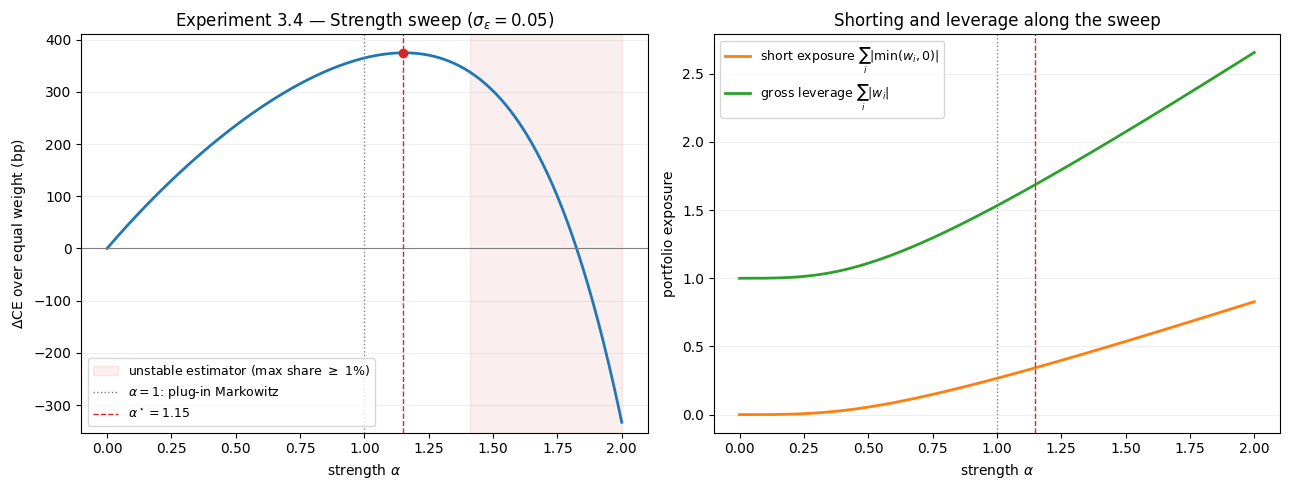


alpha* = 1.15  (max single-draw share there: 0.38%)
CE gain at alpha*: 374.7 bp over equal weight
at alpha*: short exposure = 0.34, gross leverage = 1.69
estimator unstable for alpha >= 1.41


In [12]:
sigma_eps_base = 0.05   # baseline signal noise, comparable to the drift dispersion

s_base = mu + sigma_eps_base * eps0
mask   = valid_mask(s_base)
sm, Rm = s_base[mask], R[mask]
n_kept = int(mask.sum())
print(f"normaliser guard: dropped {n_sims - n_kept} of {n_sims} replications ({(~mask).mean():.3%})")

CE_a, MSH_a, SHORT_a, LEV_a = ce_sweep(sm, alpha_grid, Rm)
astar, ce_at_astar, k = alpha_star(alpha_grid, CE_a, MSH_a)
dCE_a = 1e4 * (CE_a - CE_a[0])
unstable = MSH_a >= msh_max

# ---- numerical check 1: alpha = 1 is plug-in Markowitz exactly ----
w1    = combination_weights(sm, 1.0)
w_sig = sm / sm.sum(axis=1, keepdims=True)
print(f"alpha=1 vs w_sig: max |difference| = {np.abs(w1 - w_sig).max():.2e}")

# ---- numerical check 2: small-alpha tangency with the softmax ----
sbar = sm.mean(axis=1, keepdims=True)
for a_chk in [0.05, 0.10]:
    ce_c  = ce_of(combination_weights(sm, a_chk), Rm)
    # per-draw mapping beta = alpha / sbar (exact to first order)
    z = (a_chk / sbar) * sm; z -= z.max(axis=1, keepdims=True); e = np.exp(z)
    ce_sd = ce_of(e / e.sum(axis=1, keepdims=True), Rm)
    ce_fx = ce_of(softmax_weights(sm, a_chk / mu_bar), Rm)   # fixed mapping beta = alpha/mu_bar
    print(f"alpha={a_chk}: dCE comb = {1e4*(ce_c - CE_a[0]):5.1f} bp | per-draw softmax = "
          f"{1e4*(ce_sd - CE_a[0]):5.1f} bp | fixed-beta softmax = {1e4*(ce_fx - CE_a[0]):5.1f} bp")

# ---- plot ----
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
ax.plot(alpha_grid, dCE_a, lw=2)
if unstable.any():
    ax.axvspan(alpha_grid[unstable].min(), alpha_grid[-1], color='tab:red', alpha=0.08,
               label=f'unstable estimator (max share $\\geq$ {msh_max:.0%})')
ax.axhline(0, color='grey', lw=0.8)
ax.axvline(1.0, color='grey', ls=':', lw=1, label=r'$\alpha=1$: plug-in Markowitz')
ax.axvline(astar, color='tab:red', ls='--', lw=1, label=fr'$\alpha^\star = {astar:.2f}$')
ax.scatter([astar], [dCE_a[k]], color='tab:red', zorder=5)
ax.set_xlabel(r'strength $\alpha$')
ax.set_ylabel(r'$\Delta$CE over equal weight (bp)')
ax.set_title(fr'Experiment 3.4 — Strength sweep ($\sigma_\varepsilon = {sigma_eps_base}$)')
ax.set_ylim(1e4 * min(-0.02, (CE_a - CE_a[0]).min()) - 20, None)
ax.grid(axis='y', alpha=0.2)
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(alpha_grid, SHORT_a, lw=2, color='tab:orange', label=r'short exposure $\sum_i |\min(w_i,0)|$')
ax.plot(alpha_grid, LEV_a, lw=2, color='tab:green', label=r'gross leverage $\sum_i |w_i|$')
ax.axvline(astar, color='tab:red', ls='--', lw=1)
ax.axvline(1.0, color='grey', ls=':', lw=1)
ax.set_xlabel(r'strength $\alpha$')
ax.set_ylabel('portfolio exposure')
ax.set_title('Shorting and leverage along the sweep')
ax.grid(axis='y', alpha=0.2)
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f"\nalpha* = {astar:.2f}  (max single-draw share there: {MSH_a[k]:.2%})")
print(f"CE gain at alpha*: {dCE_a[k]:.1f} bp over equal weight")
print(f"at alpha*: short exposure = {SHORT_a[k]:.2f}, gross leverage = {LEV_a[k]:.2f}")
if unstable.any():
    print(f"estimator unstable for alpha >= {alpha_grid[unstable].min():.2f}")

**Reading.** The maximiser is **interior**: $\alpha^\star = 1.15$, just past the plug-in Markowitz point, with a peak gain of $375$ bp — against $286$ bp for the softmax on the same draws. Both anchors hold: $\alpha = 1$ reproduces $\boldsymbol{w}_{\mathrm{sig}}$ to machine precision, and near the origin the combination CE matches the per-draw-mapped softmax to within a tenth of a basis point (the fixed-$\beta$ mapping shows the predicted Jensen wedge of roughly $15\%$). The interior optimum is the notable structural result: the softmax's $\beta^\star$ could in principle be attributed to the simplex wall — concentration saturates, gains cap out — but here there is no wall, and the optimum still exists, produced by the risk–return trade-off alone. Past $\alpha^\star$ the CE falls *much* faster than the softmax's did: by $\alpha = 2$ the sweep is $330$ bp *below* equal weight, because shorting makes over-tilting genuinely dangerous rather than merely concentrated. At the optimum the book is only moderately short ($0.34$ short exposure, gross leverage $1.69$), and the stability diagnostic is comfortable there ($0.4\%$); the shaded region beyond $\alpha \approx 1.4$ is where single draws begin to dominate the utility estimate and the curve should not be trusted in detail — precisely the region where leverage passes $2$.

### The optimum in P&L terms

As in Experiment 3.1, the CE selects $\alpha^\star$; the paired P&L view shows what that optimum looks like in raw profit-and-loss. Common random numbers mean the combination portfolio and the equal-weight baseline face *identical* draws of $(\boldsymbol{\mu}, \boldsymbol{\varepsilon}, \boldsymbol{\phi})$ in every replication, so the paired difference $D = \boldsymbol{w}(\alpha^\star)^\top\boldsymbol{R} - \boldsymbol{w}(0)^\top\boldsymbol{R}$ isolates the allocation effect replication by replication. The table brackets the optimum with $\alpha \in \{0,\, 1,\, \alpha^\star,\, 1.5,\, 2\}$ — the last two columns sit in or near the unstable region deliberately, to show *in return space* what the stability diagnostic flags in utility space: the mean keeps rising while the downside quantile deteriorates much faster than it did for the softmax, because shorting makes the left tail genuinely long.

 alpha     mean      vol  P(loss) 5%quantile  P(beat 1/N)  dCE (bp)
  0.00    5.29%    4.91%    14.0%     -2.63%           --       0.0
  1.00   11.06%   10.70%    11.2%     -3.73%        77.2%     364.8
  1.15   11.93%   11.97%    11.8%     -4.36%        77.2%     374.7
  1.50   13.95%   15.04%    12.9%     -5.98%        77.2%     301.7
  2.00   16.84%   19.56%    14.3%     -8.62%        77.2%    -332.8


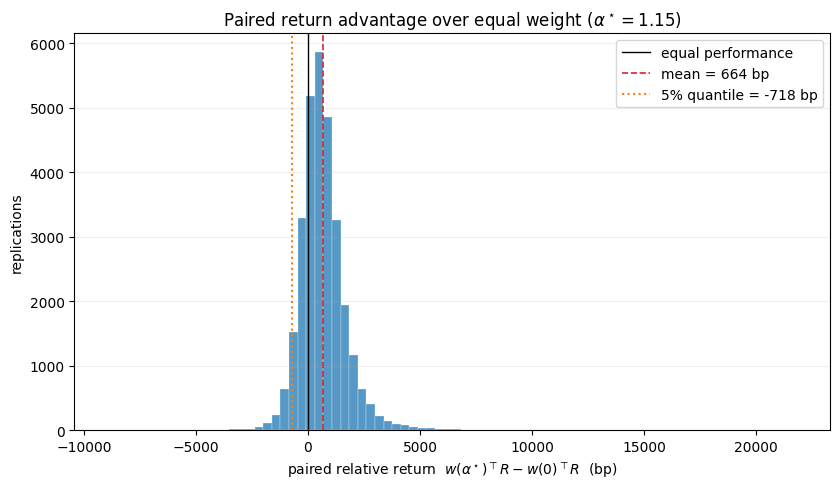

P(combination beats 1/N) = 77.2%
mean relative return = 664 bp,  5% quantile = -718 bp


In [13]:
# ---- P&L view of the CE optimum (paired against equal weight) ----
alphas_show = [0.0, 1.0, astar, 1.5, 2.0]

ports, rows = {}, []
for a in alphas_show:
    w = combination_weights(sm, a)
    p = (w * Rm).sum(axis=1)
    ports[a] = p
    ce = ce_of(w, Rm)
    rows.append((a, p.mean(), p.std(ddof=1), (p < 0).mean(),
                 np.quantile(p, 0.05),
                 (p > ports[0.0]).mean() if a > 0 else np.nan,
                 1e4 * (ce - CE_a[0])))

print(f"{'alpha':>6} {'mean':>8} {'vol':>8} {'P(loss)':>8} {'5%quantile':>10} {'P(beat 1/N)':>12} {'dCE (bp)':>9}")
for a, m, v, pl, q5, pb, dce in rows:
    pb_s = '          --' if np.isnan(pb) else f'{pb:>12.1%}'
    print(f"{a:>6.2f} {m:>8.2%} {v:>8.2%} {pl:>8.1%} {q5:>10.2%} {pb_s} {dce:>9.1f}")

d = ports[astar] - ports[0.0]
q05_d = np.quantile(d, 0.05)

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.hist(1e4 * d, bins=80, color='tab:blue', alpha=0.75, edgecolor='white', linewidth=0.25)
ax.axvline(0, color='black', lw=1.0, label='equal performance')
ax.axvline(1e4 * d.mean(), color='tab:red', ls='--', lw=1.2,
           label=fr'mean = {1e4 * d.mean():.0f} bp')
ax.axvline(1e4 * q05_d, color='tab:orange', ls=':', lw=1.5,
           label=fr'5% quantile = {1e4 * q05_d:.0f} bp')
ax.set_xlabel(r'paired relative return  $w(\alpha^\star)^\top R - w(0)^\top R$  (bp)')
ax.set_ylabel('replications')
ax.set_title(fr'Paired return advantage over equal weight ($\alpha^\star = {astar:.2f}$)')
ax.grid(axis='y', alpha=0.2)
ax.legend()
plt.tight_layout(); plt.show()

print(f"P(combination beats 1/N) = {(d > 0).mean():.1%}")
print(f"mean relative return = {1e4 * d.mean():.0f} bp,  5% quantile = {1e4 * q05_d:.0f} bp")

### Shift-invariance: a structural difference

The softmax satisfies $\operatorname{softmax}(\beta(\boldsymbol{s} + c\mathbf{1})) = \operatorname{softmax}(\beta\boldsymbol{s})$ for any constant $c$: only cross-sectional *differences* in the signal matter, never its level. The combination map does not — $c$ enters the normaliser $\mathbf{1}^\top\boldsymbol{s} + Nc$, so shifting all views up makes $\boldsymbol{w}_{\mathrm{sig}}$ *less* aggressive (deviations are divided by a larger total) and shifting them down makes it more aggressive. The check below verifies the softmax invariance to machine precision and traces the combination sweep for shifted signals $\boldsymbol{s} + c\mathbf{1}$.

The extreme case is instructive: **fully demeaning the signal** ($c = -\bar\mu$) centres the normaliser on zero, so $\boldsymbol{w}_{\mathrm{sig}}$ explodes or flips sign on roughly half the draws and the map is effectively undefined. What the softmax treats as a harmless reparametrisation is, for the combination portfolio, the difference between a working allocation rule and a meaningless one. This is the concrete sense in which the signal *level* $\bar\mu$ — irrelevant throughout Experiment 3 — becomes load-bearing the moment the map leaves the simplex.

softmax under shifts: max |weight difference| = 5.55e-16


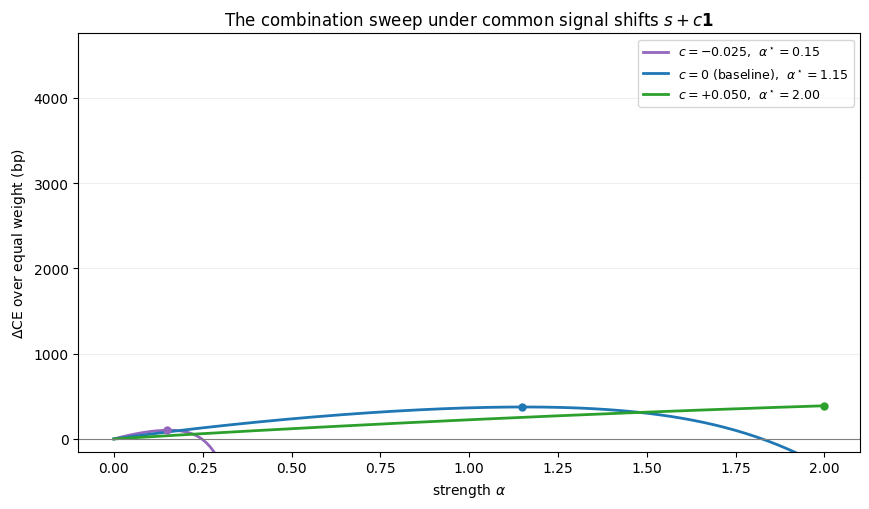

demeaned signal (c = -mu_bar): normaliser negative on 50.0% of draws (the tangency leg flips direction on a coin flip); guard would drop 5.4% — the map stops being usable


In [14]:
# ---- shift-invariance check ----
c_shifts = [-0.025, 0.0, +0.05]

# softmax: weights identical under any common shift (to machine precision)
w_ref = softmax_weights(sm, 21.0)
max_dev = max(np.abs(softmax_weights(sm + c, 21.0) - w_ref).max() for c in c_shifts if c != 0)
print(f"softmax under shifts: max |weight difference| = {max_dev:.2e}")

# combination: the sweep itself moves
fig, ax = plt.subplots(figsize=(8.8, 5.2))
for c, col in zip(c_shifts, ['tab:purple', 'tab:blue', 'tab:green']):
    s_c    = s_base + c
    mask_c = valid_mask(s_c)
    CE_c, MSH_c, _, _ = ce_sweep(s_c[mask_c], alpha_grid, R[mask_c])
    a_c, _, k_c = alpha_star(alpha_grid, CE_c, MSH_c)
    lbl = (r'$c=0$ (baseline)' if c == 0 else fr'$c={c:+.3f}$') + fr',  $\alpha^\star={a_c:.2f}$'
    ax.plot(alpha_grid, 1e4 * (CE_c - CE_c[0]), lw=2, color=col, label=lbl)
    ax.scatter([a_c], [1e4 * (CE_c[k_c] - CE_c[0])], color=col, zorder=5, s=25)
ax.axhline(0, color='grey', lw=0.8)
ax.set_xlabel(r'strength $\alpha$')
ax.set_ylabel(r'$\Delta$CE over equal weight (bp)')
ax.set_title(r'The combination sweep under common signal shifts $s + c\mathbf{1}$')
ax.set_ylim(-150, None)
ax.grid(axis='y', alpha=0.2)
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

# the demeaned extreme: shift by c = -mu_bar so the normaliser is centred on zero
s_dm = s_base - mu_bar
ns_dm = s_dm.sum(axis=1)
print(f"demeaned signal (c = -mu_bar): normaliser negative on {(ns_dm < 0).mean():.1%} of draws "
      f"(the tangency leg flips direction on a coin flip); guard would drop "
      f"{(~valid_mask(s_dm)).mean():.1%} — the map stops being usable")

**Reading.** The softmax's weights do not move under any common shift ($5.6 \times 10^{-16}$, i.e. floating-point noise); the combination sweep visibly does. An upward shift makes the map *more conservative* per unit $\alpha$ (a larger normaliser divides the same cross-sectional deviations), pushing $\alpha^\star$ up; a downward shift does the opposite. The demeaned extreme makes the point sharply: at $c = -\bar\mu$ the tangency leg's direction becomes a coin flip — the normaliser is negative on half the draws — and the map is unusable. The practical content for the thesis: the softmax reads the signal purely *cross-sectionally*, while the combination map also reads its *level* — the same object that decides between "the market is good, lever into it" and "the market is bad, short it" in unconstrained mean–variance. On the simplex that distinction cannot be expressed; off the simplex it is load-bearing, and a signal calibrated only up to a common constant (a ranking dressed as a return forecast) is safe input for the first map and unsafe for the second.

## Experiment 3.5 — Signal quality

Vary the signal-noise level $\sigma_\varepsilon$ and track the optimal strength $\alpha^\star(\sigma_\varepsilon)$. Prediction: $\alpha^\star$ retreats towards $0$ as the signal degrades. The sweep uses the extended grid $\alpha \in [0,4]$ because near-clean signals push the optimum well past the Markowitz point $\alpha = 1$.

**The within-model shrinkage benchmark.** The Bayesian posterior mean of the drift is $\mathbb{E}[\mu_i \mid s_i] = \bar\mu + \kappa(s_i - \bar\mu)$ with $\kappa = \sigma_\mu^2/(\sigma_\mu^2 + \sigma_\varepsilon^2)$. Feeding the posterior into $\boldsymbol{w}_{\mathrm{sig}}$ and approximating the normaliser by its mean ($\mathbf{1}^\top\boldsymbol{s} \approx N\bar\mu$, accurate for large $N$) gives $\boldsymbol{w}_{\mathrm{sig}}(\hat{\boldsymbol{s}}) \approx \kappa\, \boldsymbol{w}_{\mathrm{sig}}(\boldsymbol{s}) + (1-\kappa)\, \boldsymbol{w}_{\mathrm{eq}}$ — acting on the posterior at strength $\alpha$ is acting on the raw signal at strength $\alpha\kappa$. The benchmark is therefore the same $\kappa$-throttle as Experiment 3.2:
$$
\alpha^\star(\sigma_\varepsilon) \;\approx\; \alpha^\star_{\mathrm{clean}} \cdot \frac{\sigma_\mu^2}{\sigma_\mu^2 + \sigma_\varepsilon^2}.
$$
Unlike the softmax case, however, the linear map gives noise a second channel: $\varepsilon$ inflates not only the *ranking* errors but the *leverage* of $\boldsymbol{w}_{\mathrm{sig}}$ itself (noisier signals produce wilder tangency legs, and more near-zero normalisers — the dropped counts below grow with $\sigma_\varepsilon$). The interesting question is whether the retreat matches $\kappa$ or is faster.

**The Tu–Zhou benchmark, and its limits.** Tu & Zhou (2011) derive the optimal combination coefficient for exactly this $1/N$-plus-tangency blend in closed form — but for **sampling error**: their tangency leg is estimated from $T$ historical observations, and their coefficient trades the strategies' expected-utility gap against parameter-estimation risk that shrinks like $N/T$. Here the tangency leg is corrupted by **signal noise** with known $\Sigma$, which corresponds to their mean-estimation channel only (their result also prices covariance estimation error, absent here by construction until Experiment 3.6). The structural prediction survives the translation — the optimal weight on the sophisticated leg increases with its statistical reliability and tends to $0$ as the leg becomes noise — and that is what is tested quantitatively via the $\kappa$ benchmark; a numerical identification of $\alpha^\star$ with their formula would require mapping $\sigma_\varepsilon^2$ to an effective $N/T$, which is deferred to the general-framework chapter.

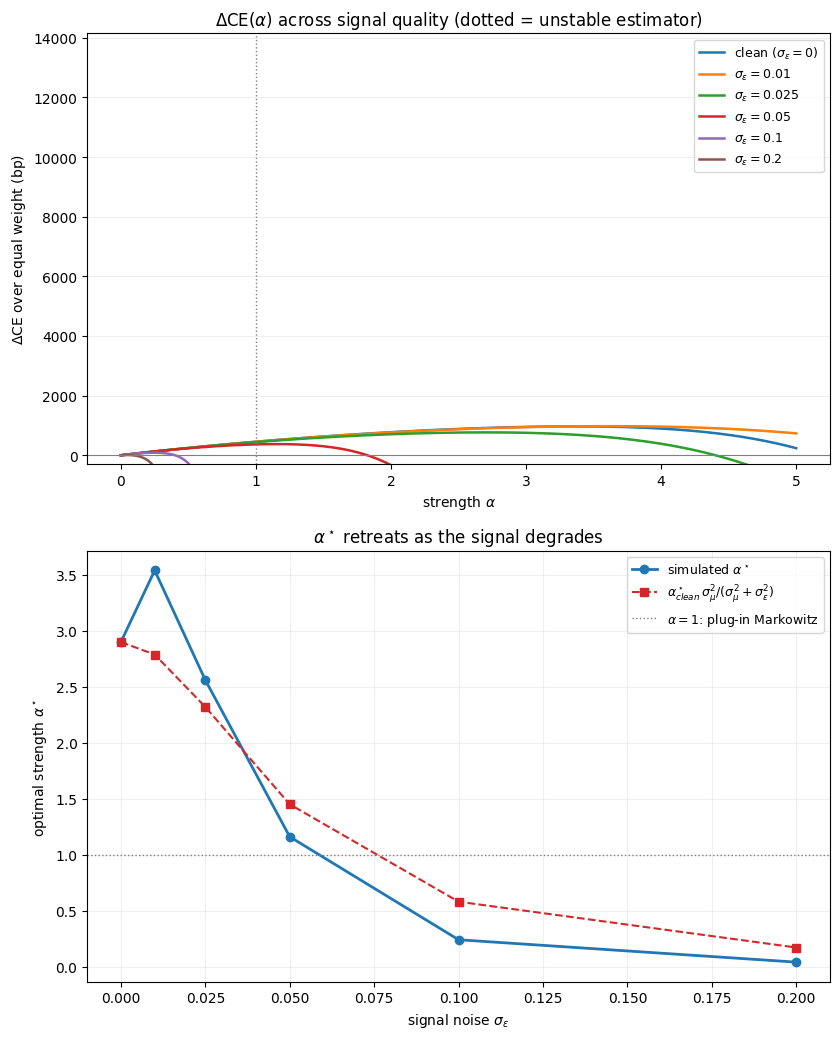

 sigma_eps   alpha*  kappa pred.  peak dCE (bp)  dropped  maxshare@opt
       0.0     2.90         2.90          941.9        0         0.96%
      0.01     3.54         2.79          975.9        0         0.98%
     0.025     2.56         2.32          765.2        1         1.00%
      0.05     1.16         1.45          374.7       41         0.39%
       0.1     0.24         0.58           85.8      649         0.14%
       0.2     0.04         0.17            9.6     1503         0.01%


In [15]:
# ---- sweep alpha at each signal-noise level ----
# The noise ladder runs from the clean signal to one dominated by noise. The mask is
# rebuilt at each level because it depends on the signal, so the dropped count climbs
# with sigma_eps; comparisons are paired within a sweep, not across levels.
sigma_eps_levels = [0.0, 0.01, 0.025, 0.05, 0.10, 0.20]
results35 = {}
for se in sigma_eps_levels:
    s_l    = mu + se * eps0
    mask_l = valid_mask(s_l)
    CE_l, MSH_l, _, _ = ce_sweep(s_l[mask_l], alpha_grid_ext, R[mask_l])
    results35[se] = (CE_l, MSH_l, int((~mask_l).sum()))

# ---- top panel: the DeltaCE curves themselves; bottom panel: where their optima sit ----
fig, axes = plt.subplots(2, 1, figsize=(8.5, 10.5))
ax = axes[0]
for se in sigma_eps_levels:
    CE_l, MSH_l, _ = results35[se]
    label = 'clean ($\\sigma_\\varepsilon=0$)' if se == 0 else fr'$\sigma_\varepsilon={se}$'
    dce = 1e4 * (CE_l - CE_l[0])
    ln, = ax.plot(alpha_grid_ext, dce, lw=1.8, label=label)
    # solid where the CARA average is trustworthy, dotted where one draw dominates it
    bad = MSH_l >= msh_max
    if bad.any():   # dotted where the estimator is unstable
        dce_bad = np.where(bad, dce, np.nan)
        ax.plot(alpha_grid_ext, dce_bad, lw=1.2, ls=':', color=ln.get_color())
ax.axhline(0, color='grey', lw=0.8)
ax.axvline(1.0, color='grey', ls=':', lw=1)
ax.set_xlabel(r'strength $\alpha$')
ax.set_ylabel(r'$\Delta$CE over equal weight (bp)')
ax.set_title(r'$\Delta$CE$(\alpha)$ across signal quality (dotted = unstable estimator)')
ax.set_ylim(-300, None)
ax.grid(axis='y', alpha=0.2)
ax.legend(fontsize=9)

# ---- optimal strength against the Bayesian shrinkage benchmark ----
# kappa = sigma_mu^2 / (sigma_mu^2 + sigma_eps^2) is the posterior weight on the signal;
# the benchmark is that curve anchored at the clean-signal optimum. alpha_star() searches
# only the stable region, so a value pinned at the shading boundary is a lower bound.
astars35 = np.array([alpha_star(alpha_grid_ext, *results35[se][:2])[0] for se in sigma_eps_levels])
kappa    = sigma_mu**2 / (sigma_mu**2 + np.array(sigma_eps_levels)**2)
pred     = astars35[0] * kappa

ax = axes[1]
ax.plot(sigma_eps_levels, astars35, 'o-', lw=2, label=r'simulated $\alpha^\star$')
ax.plot(sigma_eps_levels, pred, 's--', lw=1.5, color='tab:red',
        label=r'$\alpha^\star_{clean}\,\sigma_\mu^2/(\sigma_\mu^2+\sigma_\varepsilon^2)$')
ax.axhline(1.0, color='grey', ls=':', lw=1, label=r'$\alpha=1$: plug-in Markowitz')
ax.set_xlabel(r'signal noise $\sigma_\varepsilon$')
ax.set_ylabel(r'optimal strength $\alpha^\star$')
ax.set_title(r'$\alpha^\star$ retreats as the signal degrades')
ax.grid(alpha=0.2)
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f"{'sigma_eps':>10} {'alpha*':>8} {'kappa pred.':>12} {'peak dCE (bp)':>14} {'dropped':>8} {'maxshare@opt':>13}")
for se, a_s, pr in zip(sigma_eps_levels, astars35, pred):
    CE_l, MSH_l, drop = results35[se]
    _, _, kk = alpha_star(alpha_grid_ext, CE_l, MSH_l)
    print(f"{se:>10} {a_s:>8.2f} {pr:>12.2f} {1e4*(CE_l[kk]-CE_l[0]):>14.1f} {drop:>8} {MSH_l[kk]:>13.2%}")

**Reading.** The retreat is confirmed and is **faster than the $\kappa$ benchmark**: at $\sigma_\varepsilon = 0.05$ the simulated $\alpha^\star = 1.16$ against a predicted $1.45$; at $0.10$, $0.24$ against $0.58$; at $0.20$, $0.04$ against $0.17$. The softmax tracked its $\kappa$ curve closely (Experiment 3.2); the combination map retreats harder because noise costs it through **two channels**: it dilutes the ranking information (the Bayesian channel, priced by $\kappa$) *and* it inflates the tangency leg itself — noisier signals produce wilder $\boldsymbol{w}_{\mathrm{sig}}$, more leverage per unit $\alpha$, and more near-degenerate normalisers (the dropped count climbs from $41$ to $649$ to $1503$ across the noise ladder). The second channel has no softmax analogue, because the simplex caps how wild the weights can get. On the near-clean side, the reported optima ($\alpha^\star \approx 2.9$–$3.5$ for $\sigma_\varepsilon \leq 0.025$) sit exactly at the estimator-stability threshold (max single-draw shares of $\approx 1\%$) — they should be read as *stability-truncated lower bounds*, not sharp locations, and the wiggle among them (e.g. $2.90 \to 3.54$) is the truncation binding at slightly different points, not economics. Qualitatively this is the Tu–Zhou prediction — the weight on the sophisticated leg rises with its reliability and dies with noise — reproduced in the signal-noise (rather than sampling-error) parametrisation. The $\alpha$ grid was extended to $[0,5]$ to make sure the near-clean optima were not simply running off the end of the sweep: they do not move (still $2.90$, $3.54$, $2.56$), which confirms they are bound by the **estimator**, not by the grid — no amount of extra grid resolves them, only more replications would.

### Two ways to read the diagnostic: at the optimum, and at a fixed tilt

The `maxshare@opt` column above *falls* as the signal degrades — $0.96\% \to 0.39\% \to 0.14\% \to 0.01\%$ — which invites the conclusion that noise makes the estimator better behaved. It does not. The column is evaluated at $\alpha^\star$, and $\alpha^\star$ is itself collapsing ($2.90 \to 1.16 \to 0.24 \to 0.04$), so two things move at once and the comparison confounds them.

Holding $\alpha$ **fixed** separates the two effects, and the sign reverses:

* **At a fixed tilt, noise is severely destabilising.** A noisier signal produces a wilder tangency leg, so at the same $\alpha$ the portfolio carries more gross leverage and deeper short positions. Unbounded losses follow, CARA exponentiates them, and the average falls under the control of a handful of draws.
* **At the optimum, noise appears stabilising — but only as a by-product.** The optimiser responds to a degraded signal by retreating towards equal weight, where the weights are (nearly) non-negative, the portfolio return is bounded below by $-1$, and no replication can dominate. The safety comes from tilting less, not from the signal being better.

The cell below runs the controlled version: the same noise ladder, with $\alpha$ pinned at the baseline optimum $1.15$ throughout, reporting the diagnostic and the gross leverage that drives it. It is also the direct evidence for the *second channel* asserted in the reading above — the one that has no softmax analogue, and that pushes $\alpha^\star$ below the $\kappa$ benchmark.

In [16]:
# ---- the diagnostic at a FIXED tilt, so that only the signal noise varies ----
a_fixed = astar   # the baseline optimum, 1.15

print(f"{'sigma_eps':>10} {'maxshare @ fixed alpha':>23} {'leverage':>9} {'short':>7} "
      f"{'|':>2} {'alpha*':>7} {'maxshare @ alpha*':>18}")
for se in sigma_eps_levels:
    s_l    = mu + se * eps0
    mask_l = valid_mask(s_l)
    s_m, R_m = s_l[mask_l], R[mask_l]
    w_sig_l  = s_m / s_m.sum(axis=1, keepdims=True)

    # (a) fixed alpha: noise is the only thing changing
    w = (1.0 - a_fixed) / N + a_fixed * w_sig_l
    with np.errstate(over='ignore'):
        u = np.exp(-gamma * (w * R_m).sum(axis=1))
    msh_fix = u.max() / u.sum()
    lev     = np.abs(w).sum(axis=1).mean()
    short   = np.abs(np.minimum(w, 0.0)).sum(axis=1).mean()

    # (b) at that level's own optimum, for comparison (as reported above)
    CE_l, MSH_l, _ = results35[se]
    a_s, _, kk = alpha_star(alpha_grid_ext, CE_l, MSH_l)

    print(f"{se:>10} {msh_fix:>23.2%} {lev:>9.2f} {short:>7.2f} {'|':>2} "
          f"{a_s:>7.2f} {MSH_l[kk]:>18.2%}")

 sigma_eps  maxshare @ fixed alpha  leverage   short  |  alpha*  maxshare @ alpha*
       0.0                   0.03%      1.28    0.14  |    2.90              0.96%
      0.01                   0.02%      1.29    0.15  |    3.54              0.98%
     0.025                   0.06%      1.38    0.19  |    2.56              1.00%
      0.05                   0.38%      1.69    0.34  |    1.16              0.39%
       0.1                  70.24%      2.85    0.92  |    0.24              0.14%
       0.2                  97.42%      5.58    2.29  |    0.04              0.01%


**Reading.** The two right-hand columns are the table from Experiment 3.5, and they fall with noise; the two left-hand columns hold $\alpha = 1.15$ and rise catastrophically — $0.03\% \to 0.38\% \to 70\% \to 97\%$. At $\sigma_\varepsilon = 0.20$ a single replication out of $30{,}000$ carries $97\%$ of the estimated expected utility: the number is not an average, it is one draw.

The leverage column supplies the mechanism. At an unchanged $\alpha$, degrading the signal takes gross leverage from $1.28$ to $5.58$ and short exposure from $0.14$ to $2.29$ — at the noisiest level the book is short more than twice its own capital. Noise does not merely blur the ranking the tilt acts on; it inflates the object being tilted towards, because $\boldsymbol{w}_{\mathrm{sig}} = \boldsymbol{s} / (\mathbf{1}^\top\boldsymbol{s})$ divides by a normaliser that noise pushes towards zero. That is the **second channel**: the $\kappa$ benchmark prices the loss of information, but not the loss of control over the leg's magnitude, and it is why $\alpha^\star$ falls below the benchmark rather than tracking it.

Two consequences worth carrying forward. First, the apparent stabilisation at the optimum is entirely a *behavioural* effect — the optimiser abandons the tilt ($\alpha^\star = 0.04$ at the noisiest level, a portfolio that is $96\%$ equal weight) and inherits the equal-weight portfolio's boundedness. Read as a statement about the map, noise makes the estimator worse everywhere; read as a statement about the *optimised* portfolio, the damage is hidden because the optimiser has already fled. Second, the clean end of the ladder is not the safe end it appears: at $\sigma_\varepsilon = 0$ the map is perfectly well behaved at $\alpha = 1.15$ ($0.03\%$), and becomes fragile only because a clean signal justifies pushing $\alpha$ towards $2.9$ and beyond. A clean signal is not dangerous in itself; it is dangerous because it invites leverage.

## Experiment 3.6 — Volatility signal and covariance estimation error

So far $\Sigma$ was known (and trivial). This experiment makes the risk model *estimated*, in the simplest setting that isolates the effect: volatilities become heterogeneous, $\sigma_i$ drawn per replication from a cross-section ($\sigma_i \sim \mathcal{N}(\bar\sigma, \sigma_\sigma^2)$ clipped below at $0.05$, with $\bar\sigma = 0.20$, $\sigma_\sigma = 0.05$), assets stay uncorrelated, and a **vol-tracking signal** replaces the true $\sigma_i$ in the weights: $\hat\sigma_i = \sigma_i\, e^{\nu\eta_i - \nu^2/2}$, $\eta_i \sim \mathcal{N}(0,1)$, so $\hat\Sigma = \operatorname{diag}(\hat\sigma_i^2)$ and $\nu = 0$ is the oracle. The noise is multiplicative because volatility estimates are positive by nature; an additive specification would generate negative $\hat\sigma_i$ purely as an artefact of the noise model and force wholesale dropping of draws.

**The structural asymmetry under test.** The drift signal enters $\boldsymbol{w}_{\mathrm{sig}} = \hat\Sigma^{-1}\boldsymbol{s}\,/\,\mathbf{1}^\top\hat\Sigma^{-1}\boldsymbol{s}$ *linearly* through the numerator, so drift noise dilutes the tilt smoothly — the clean $\kappa$-shrinkage of Experiment 3.5. The vol signal enters through the **inversion** $\hat\sigma_i^{-2}$: an underestimate of a name's volatility is amplified into an aggressive overweight of exactly the name whose risk was misjudged, and the error is convex (halving $\hat\sigma$ quadruples the weight multiplier). The prediction, following the estimation-error literature surveyed in Chapter 2 (Best & Grauer 1991; Chopra & Ziemba 1993), is that CE degrades with vol noise **harder and more erratically** than with drift noise.

Part (i) sweeps the vol-noise level $\nu$ (drift noise fixed at its baseline) against a control that sweeps drift noise (vol known), each with the optimal $\alpha$ re-selected. Part (ii) runs the **two-loading experiment**: shrink the drift signal towards $\bar\mu$ with loading $a_\mu$ and the vol signal towards the cross-sectional mean variance with loading $a_\sigma$,
$$
\hat{s}_i = \bar\mu + a_\mu (s_i - \bar\mu), \qquad
\tilde\sigma_i^2 = \overline{\sigma^2} + a_\sigma (\hat\sigma_i^2 - \overline{\sigma^2}),
\qquad
\boldsymbol{w} \propto \tilde\Sigma^{-1}\hat{\boldsymbol{s}}\ \ \text{(normalised)},
$$
and maps the CE surface over $(a_\mu, a_\sigma)$, testing the "loading $\propto$ precision" hypothesis: the Bayesian loadings would be $\kappa_\mu = \sigma_\mu^2/(\sigma_\mu^2+\sigma_\varepsilon^2)$ and, on the log-vol scale, $\kappa_\sigma \approx d^2/(d^2+\nu^2)$ with $d = \sigma_\sigma/\bar\sigma$ the dispersion of $\ln\sigma_i$.

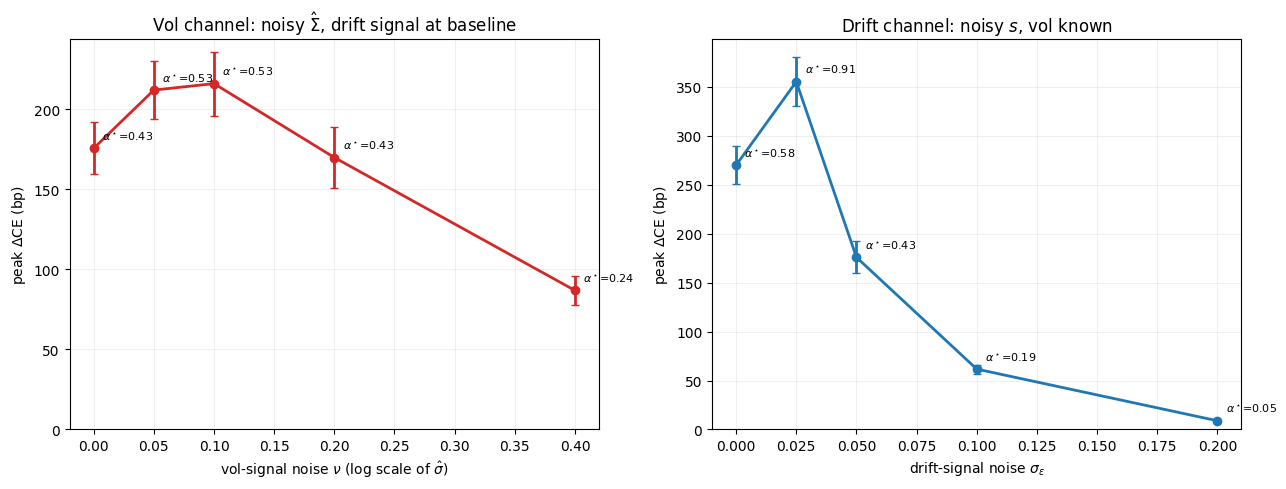

 channel  noise  alpha*  peak dCE (bp)  +/- SE  dropped  maxshare@opt
     vol    0.0    0.43          175.7      16      231         0.60%
     vol   0.05    0.53          212.1      18      251         0.77%
     vol    0.1    0.53          216.1      20      269         0.96%
     vol    0.2    0.43          170.0      19      298         0.85%
     vol    0.4    0.24           86.9       9      471         0.39%
   drift    0.0    0.58          269.9      19       27         0.96%
   drift  0.025    0.91          355.1      25       62         0.79%
   drift   0.05    0.43          175.7      16      231         0.60%
   drift    0.1    0.19           61.6       5      938         0.16%
   drift    0.2    0.05            8.9       1     1602         0.02%


In [17]:
# ---- Experiment 3.6 setup: heterogeneous vols and a vol-tracking signal ----
rng_vol   = np.random.default_rng(4343)
sigma_bar, sigma_sig = 0.20, 0.05
sig_i = np.clip(sigma_bar + sigma_sig * rng_vol.standard_normal((n_sims, N)), 0.05, None)
eta0  = rng_vol.standard_normal((n_sims, N))          # standardised vol-signal noise
R_het = np.exp((mu - 0.5 * sig_i**2) * dt + sig_i * np.sqrt(dt) * phi) - 1.0   # same mu, phi (CRN)

def sweep_36(s_l, sighat, grid=alpha_grid):
    Vinv = 1.0 / sighat**2
    num  = s_l * Vinv                                   # diag Sigma: elementwise
    ns   = num.sum(axis=1)
    mask = np.abs(ns) > 0.10 * np.median(np.abs(ns))
    w_sig = num[mask] / ns[mask, None]
    Rl = R_het[mask]
    CE, MSH = np.empty(len(grid)), np.empty(len(grid))
    for k, a in enumerate(grid):
        w = (1.0 - a) / N + a * w_sig
        with np.errstate(over='ignore'):
            u = np.exp(-gamma * (w * Rl).sum(axis=1))
        CE[k] = -np.log(u.mean()) / gamma
        MSH[k] = u.max() / u.sum()
    # paired delta-method SE of dCE at the (stable) optimum
    a_s, _, kk = alpha_star(grid, CE, MSH)
    w = (1.0 - a_s) / N + a_s * w_sig
    u1 = np.exp(-gamma * (w * Rl).sum(axis=1)); u0 = np.exp(-gamma * Rl.mean(axis=1))
    infl = u1 / (gamma * u1.mean()) - u0 / (gamma * u0.mean())
    se_d = infl.std(ddof=1) / np.sqrt(mask.sum())
    return CE, MSH, int((~mask).sum()), a_s, kk, se_d

# part (i): vol-noise sweep (drift noise at baseline) vs drift-noise control (vol known)
s36 = mu + sigma_eps_base * eps0
nu_levels = [0.0, 0.05, 0.10, 0.20, 0.40]
se_levels_ctrl = [0.0, 0.025, 0.05, 0.10, 0.20]

res_vol, res_drift = {}, {}
for nu in nu_levels:
    sighat = sig_i * np.exp(nu * eta0 - 0.5 * nu**2)
    res_vol[nu] = sweep_36(s36, sighat)
for se in se_levels_ctrl:
    res_drift[se] = sweep_36(mu + se * eps0, sig_i)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, res, xlab, ttl, col in [
        (axes[0], res_vol, r'vol-signal noise $\nu$ (log scale of $\hat\sigma$)',
         'Vol channel: noisy $\\hat\\Sigma$, drift signal at baseline', 'tab:red'),
        (axes[1], res_drift, r'drift-signal noise $\sigma_\varepsilon$',
         'Drift channel: noisy $s$, vol known', 'tab:blue')]:
    xs = list(res.keys())
    peaks = [1e4 * (res[x][0][res[x][4]] - res[x][0][0]) for x in xs]
    errs  = [1e4 * res[x][5] for x in xs]
    ax.errorbar(xs, peaks, yerr=errs, fmt='o-', lw=2, capsize=3, color=col)
    for x in xs:
        ax.annotate(fr'$\alpha^\star$={res[x][3]:.2f}', (x, 1e4*(res[x][0][res[x][4]] - res[x][0][0])),
                    textcoords='offset points', xytext=(6, 6), fontsize=8)
    ax.set_xlabel(xlab); ax.set_ylabel(r'peak $\Delta$CE (bp)')
    ax.set_title(ttl); ax.grid(alpha=0.2)
axes[0].set_ylim(0, None); axes[1].set_ylim(0, None)
plt.tight_layout(); plt.show()

print(f"{'channel':>8} {'noise':>6} {'alpha*':>7} {'peak dCE (bp)':>14} {'+/- SE':>7} {'dropped':>8} {'maxshare@opt':>13}")
for nu in nu_levels:
    CE, MSH, drop, a_s, kk, se_d = res_vol[nu]
    print(f"{'vol':>8} {nu:>6} {a_s:>7.2f} {1e4*(CE[kk]-CE[0]):>14.1f} {1e4*se_d:>7.0f} {drop:>8} {MSH[kk]:>13.2%}")
for se in se_levels_ctrl:
    CE, MSH, drop, a_s, kk, se_d = res_drift[se]
    print(f"{'drift':>8} {se:>6} {a_s:>7.2f} {1e4*(CE[kk]-CE[0]):>14.1f} {1e4*se_d:>7.0f} {drop:>8} {MSH[kk]:>13.2%}")

**Reading.** The two channels degrade in visibly different ways, though not in the way a naive reading of "covariance errors hurt more" would suggest. The **drift channel** collapses steeply and smoothly once noise is material: $355 \to 176 \to 62 \to 9$ bp along $\sigma_\varepsilon = 0.025 \to 0.2$, with $\alpha^\star$ throttling in sympathy ($0.91 \to 0.05$) — the $\kappa$-shrinkage picture again. The **vol channel** is shallower and bumpier: the peak drifts $176 \to 212 \to 216 \to 170 \to 87$ bp as $\nu$ runs to $0.4$, differences of only $\sim 2$ paired standard errors between adjacent levels, and — the striking part — $\boldsymbol{\alpha^\star}$ **barely moves** ($0.43$–$0.53$) until the noise is extreme. Vol noise does not announce itself through the strength dial the way drift noise does; it degrades quietly and erratically, and its cost concentrates in the tails: across both channels the *low*-noise entries have max single-draw shares near the $1\%$ threshold, so the low-noise peaks (including the apparent non-monotonicities, e.g. the drift channel's $270 \to 355$) are stability-truncated lower bounds whose exact values should not be over-read. That is the operational form of the Best–Grauer/Chopra–Ziemba asymmetry in this lab: mean errors are *priced* by the optimiser (visible retreat), volatility errors are *amplified* by the inversion into occasional violent misallocations that the average hides and the tail diagnostic exposes.

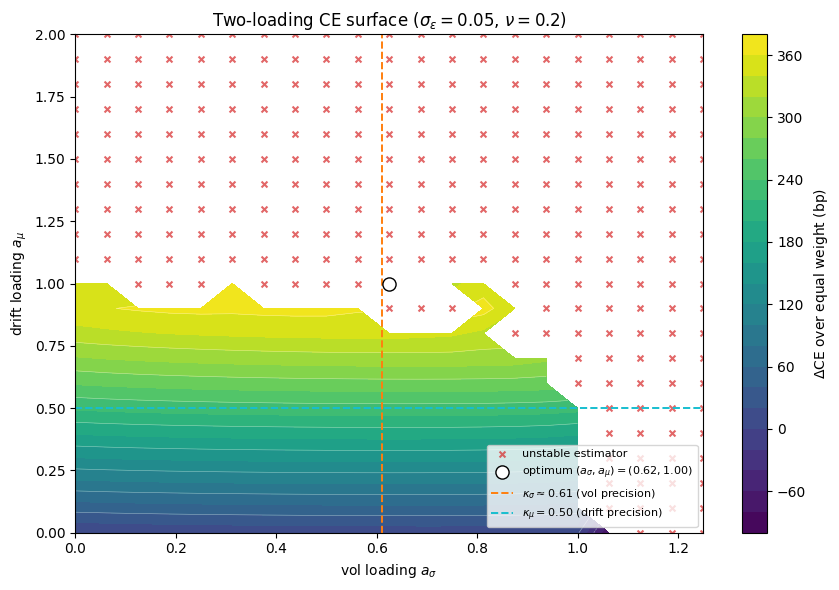

optimum: a_mu = 1.00, a_sigma = 0.62, dCE = 375.9 bp, maxshare there 0.31%
precision benchmarks: kappa_mu = 0.50, kappa_sigma = 0.61
unstable cells: 273 of 441
draws dropped at the optimum: 94 of 30000; baseline shift from pairing: 0.6 bp

ridge along a_mu (a_sigma at optimum): [  7. 191. 347.  nan  nan  nan]
ridge along a_sigma (a_mu at optimum): [344.  nan  nan 336.  nan  nan]


In [18]:
# ---- part (ii): the two-loading experiment ----
nu_36   = 0.20                                   # vol-signal noise for the surface
sighat  = sig_i * np.exp(nu_36 * eta0 - 0.5 * nu_36**2)
var_bar = sigma_bar**2 + sigma_sig**2            # cross-sectional mean of sigma_i^2

amu_grid = np.linspace(0.0, 2.0, 21)             # drift loading (past 1: anti-shrinkage allowed)
avol_grid = np.linspace(0.0, 1.25, 21)           # vol loading

CEmat  = np.full((len(amu_grid), len(avol_grid)), np.nan)
CE0mat = np.full_like(CEmat, np.nan)      # equal-weight baseline on each cell's own masked sample
MSHmat = np.zeros_like(CEmat)
DROPmat = np.zeros_like(CEmat)
for i, am in enumerate(amu_grid):
    shat = mu_bar + am * (s36 - mu_bar)
    for j, av in enumerate(avol_grid):
        vtil = var_bar + av * (sighat**2 - var_bar)
        num  = shat / vtil
        ns   = num.sum(axis=1)
        m_ij = np.abs(ns) > 0.10 * np.median(np.abs(ns))
        w    = num[m_ij] / ns[m_ij, None]
        R_ij = R_het[m_ij]
        with np.errstate(over='ignore'):
            u = np.exp(-gamma * (w * R_ij).sum(axis=1))
        CEmat[i, j]  = -np.log(u.mean()) / gamma
        # the mask varies from cell to cell, so the baseline is recomputed on the same
        # draws: dCE is then a paired difference everywhere on the surface
        CE0mat[i, j] = ce_of(np.full((int(m_ij.sum()), N), 1.0 / N), R_ij)
        MSHmat[i, j] = u.max() / u.sum()
        DROPmat[i, j] = int((~m_ij).sum())

stable = MSHmat < msh_max
CEplot = np.where(stable, 1e4 * (CEmat - CE0mat), np.nan)
i_s, j_s = np.unravel_index(np.nanargmax(CEplot), CEplot.shape)
amu_s, avol_s = amu_grid[i_s], avol_grid[j_s]

kappa_mu  = sigma_mu**2 / (sigma_mu**2 + sigma_eps_base**2)
d_logvol  = sigma_sig / sigma_bar
kappa_vol = d_logvol**2 / (d_logvol**2 + nu_36**2)

fig, ax = plt.subplots(figsize=(8.8, 6))
cf = ax.contourf(avol_grid, amu_grid, CEplot, levels=24, cmap='viridis')
ax.contour(avol_grid, amu_grid, CEplot, levels=12, colors='white', linewidths=0.4, alpha=0.5)
bad = np.where(~stable)
ax.scatter(avol_grid[bad[1]], amu_grid[bad[0]], marker='x', color='tab:red', s=18,
           label=f'unstable estimator', alpha=0.7)
ax.scatter([avol_s], [amu_s], color='white', edgecolor='black', s=90, zorder=6,
           label=fr'optimum $(a_\sigma, a_\mu) = ({avol_s:.2f}, {amu_s:.2f})$')
ax.axvline(kappa_vol, color='tab:orange', ls='--', lw=1.4,
           label=fr'$\kappa_\sigma \approx {kappa_vol:.2f}$ (vol precision)')
ax.axhline(kappa_mu, color='tab:cyan', ls='--', lw=1.4,
           label=fr'$\kappa_\mu = {kappa_mu:.2f}$ (drift precision)')
plt.colorbar(cf, label=r'$\Delta$CE over equal weight (bp)')
ax.set_xlabel(r'vol loading $a_\sigma$')
ax.set_ylabel(r'drift loading $a_\mu$')
ax.set_title(fr'Two-loading CE surface ($\sigma_\varepsilon={sigma_eps_base}$, $\nu={nu_36}$)')
ax.legend(fontsize=8, loc='lower right')
plt.tight_layout(); plt.show()

print(f"optimum: a_mu = {amu_s:.2f}, a_sigma = {avol_s:.2f}, "
      f"dCE = {CEplot[i_s, j_s]:.1f} bp, maxshare there {MSHmat[i_s, j_s]:.2%}")
print(f"precision benchmarks: kappa_mu = {kappa_mu:.2f}, kappa_sigma = {kappa_vol:.2f}")
print(f"unstable cells: {(~stable).sum()} of {stable.size}")
print(f"draws dropped at the optimum: {DROPmat[i_s, j_s]:.0f} of {n_sims}; "
      f"baseline shift from pairing: {1e4*(CE0mat[i_s, j_s] - ce_of(np.full((n_sims, N), 1.0/N), R_het)):.1f} bp")
print("\nridge along a_mu (a_sigma at optimum):",
      np.array2string(CEplot[:, j_s][::4], precision=0, suppress_small=True))
print("ridge along a_sigma (a_mu at optimum):",
      np.array2string(CEplot[i_s, :][::4], precision=0, suppress_small=True))

**Reading.** The surface answers the "loading $\propto$ precision" hypothesis with a clean split. The **vol loading lands almost exactly on its precision benchmark**: $a_\sigma^\star = 0.62$ against $\kappa_\sigma \approx 0.61$ — Bayesian shrinkage of the vol signal towards the cross-sectional mean variance is CE-optimal, to within grid resolution. The **drift loading does not**: $a_\mu^\star = 1.0$ against $\kappa_\mu = 0.5$, pinned not by inference but by the edge of the stable region. The structural reason is visible in the map itself: the weights are invariant to a *uniform* scaling of $\tilde\Sigma$ (it cancels in the normalised ratio), so $a_\sigma$ acts only through *relative* variances across names — it is a pure inference dial, and the Bayesian answer applies. Scaling the drift deviations, by contrast, changes the cross-sectional aggressiveness of the tilt — $a_\mu$ is a *strength* dial wearing shrinkage clothing, and its optimum is set by the risk–return trade-off (and here, by where the estimator stops being trustworthy), not by posterior precision. The other headline is the wreckage around the optimum: $273$ of $441$ grid cells — $62\%$ of the surface — fail the stability diagnostic, essentially everywhere the drift loading is ambitious and the vol loading departs from its shrunk optimum. The two-loading landscape of a covariance-aware, shortable portfolio is mostly cliff; the walkable ridge is narrow, and its vol coordinate is precisely the Bayesian one.

## Experiment 3.7 — Correlated assets, head-to-head

The final experiment reuses the two correlation structures of Experiment 3.3 — equicorrelation at $\rho \in \{0, 0.25, 0.5\}$ (common factor $z_0$, same seed) and the seed-fixed 3-factor loading matrix — and supplies the true non-diagonal $\Sigma = \sigma^2 C\,\Delta t$ **known** to the combination map, which now uses the full inverse: $\boldsymbol{w}_{\mathrm{sig}} = \Sigma^{-1}\boldsymbol{s}/\mathbf{1}^\top\Sigma^{-1}\boldsymbol{s}$.

The point of the head-to-head: the **softmax is blind to $\Sigma$** — its weights depend on the signal alone — while the combination map can use the risk model and can short to hedge common-factor exposure. Both maps are run on the *same signal, same $\Sigma$, same draws* (softmax evaluated on the combination's masked sample, so the comparison is paired). The prediction is that the peak-$\Delta$CE gap between the two maps **widens with $\rho$**, because high correlation is precisely the regime where knowing and inverting $\Sigma$ matters.

A structural remark before the results: under equicorrelation, $\Sigma^{-1}$ **amplifies** cross-sectional signal deviations by the factor $\frac{1+(N-1)\rho}{1-\rho}$ (Sherman–Morrison) — at $\rho = 0.5$ that is a $21\times$ amplification, so the tangency leg is far more aggressive per unit of $\alpha$ and the optimal $\alpha^\star$ should collapse towards zero even as the achievable gain rises. $\alpha$ is a coordinate on a path whose parametrisation changes with $\Sigma$; comparisons across cases should be read off the achieved $\Delta$CE (or the entropy scale of the closing section), not off raw $\alpha$ values.

                  case     a*  comb peak  msh@opt   b*  sfmx peak  gap (bp)  dropped lev(w_sig) p99
      equicorr rho=0.0   1.15        375    0.38%   21        286        88       41            4.1
     equicorr rho=0.25   0.19        460    0.73%   25        322       138       41           30.9
      equicorr rho=0.5   0.08        579    0.84%   33        370       210       41           84.5
          factor model   0.12        213    0.41%   23        305       -91      411           34.4


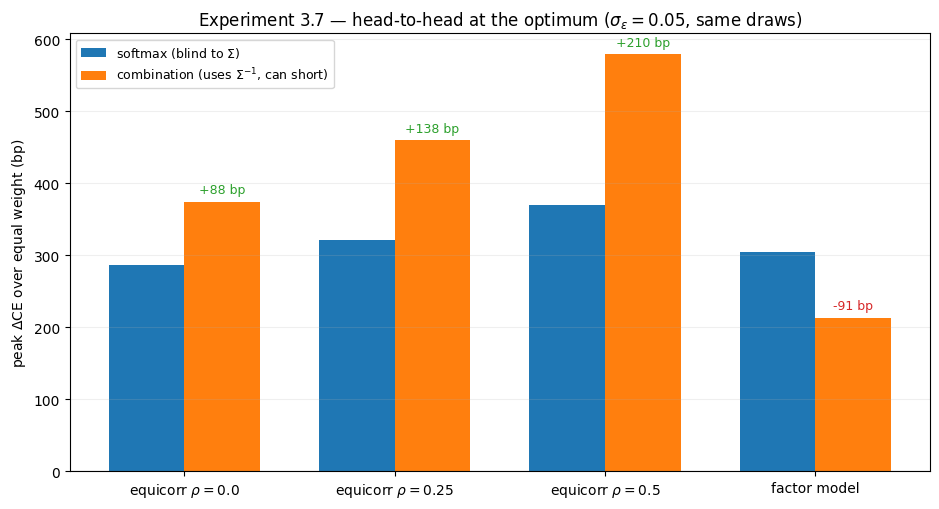

In [19]:
# ---- Experiment 3.7: correlated diffusion shocks, combination vs softmax ----
rho_levels = [0.0, 0.25, 0.5]
rng_corr = np.random.default_rng(4242)
z0 = rng_corr.standard_normal((n_sims, 1))          # common factor, shared across all rho (as in Exp 3.3)

# 3-factor loadings, identical construction and seed to Experiment 3.3
k_fac = 3
rng_fac = np.random.default_rng(7)
B = np.empty((N, k_fac))
B[:, 0]  = 0.45 + 0.15 * rng_fac.standard_normal(N)
B[:, 1:] = 0.30 * rng_fac.standard_normal((N, k_fac - 1))
norms = np.sqrt((B**2).sum(axis=1))
too_big = norms > 0.95
B[too_big] *= (0.95 / norms[too_big])[:, None]
idio = np.sqrt(1.0 - (B**2).sum(axis=1))
F = rng_fac.standard_normal((n_sims, k_fac))

cases = {}
for rho in rho_levels:
    Corr = (1 - rho) * np.eye(N) + rho * np.ones((N, N))
    phi_rho = np.sqrt(rho) * z0 + np.sqrt(1.0 - rho) * phi
    cases[fr'equicorr $\rho={rho}$'] = (Corr, phi_rho)
C_fac = B @ B.T + np.diag(idio**2)
cases['factor model'] = (C_fac, F @ B.T + phi * idio)

print(f"{'case':>22} {'a*':>6} {'comb peak':>10} {'msh@opt':>8} {'b*':>4} {'sfmx peak':>10} {'gap (bp)':>9} {'dropped':>8} {'lev(w_sig) p99':>14}")
summary = {}
for name, (Corr, phi_c) in cases.items():
    Sigma_inv = np.linalg.inv(sigma**2 * Corr * dt)
    R_c  = np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * phi_c) - 1.0
    m_c  = valid_mask(s_base, Sigma_inv)
    s_c, R_cm = s_base[m_c], R_c[m_c]

    CE_c, MSH_c, _, LEV_c = ce_sweep(s_c, alpha_grid, R_cm, Sigma_inv)
    a_c, _, k_c = alpha_star(alpha_grid, CE_c, MSH_c)
    num = s_c @ Sigma_inv.T
    lev99 = np.quantile(np.abs(num / num.sum(axis=1, keepdims=True)).sum(axis=1), 0.99)

    CE_s = np.array([ce_of(softmax_weights(s_c, b), R_cm) for b in beta_grid])
    k_s  = int(np.argmax(CE_s))

    comb_pk, sfmx_pk = 1e4 * (CE_c[k_c] - CE_c[0]), 1e4 * (CE_s[k_s] - CE_s[0])
    summary[name] = (comb_pk, sfmx_pk, a_c, beta_grid[k_s])
    clean = name.replace('$', '').replace('\\rho', 'rho')
    print(f"{clean:>22} {a_c:>6.2f} {comb_pk:>10.0f} {MSH_c[k_c]:>8.2%} {beta_grid[k_s]:>4.0f} "
          f"{sfmx_pk:>10.0f} {comb_pk - sfmx_pk:>9.0f} {(~m_c).sum():>8} {lev99:>14.1f}")

# ---- grouped bars: peak dCE, softmax vs combination ----
names = list(summary.keys())
x = np.arange(len(names)); wd = 0.36
fig, ax = plt.subplots(figsize=(9.5, 5.2))
b1 = ax.bar(x - wd/2, [summary[n][1] for n in names], wd, label='softmax (blind to $\\Sigma$)', color='tab:blue')
b2 = ax.bar(x + wd/2, [summary[n][0] for n in names], wd, label='combination (uses $\\Sigma^{-1}$, can short)', color='tab:orange')
for xi, n in zip(x, names):
    gap = summary[n][0] - summary[n][1]
    ax.annotate(f'{gap:+.0f} bp', (xi + wd/2, max(summary[n][0], 0) + 12), ha='center', fontsize=9,
                color='tab:green' if gap > 0 else 'tab:red')
ax.set_xticks(x); ax.set_xticklabels(names)
ax.axhline(0, color='grey', lw=0.8)
ax.set_ylabel(r'peak $\Delta$CE over equal weight (bp)')
ax.set_title(fr'Experiment 3.7 — head-to-head at the optimum ($\sigma_\varepsilon={sigma_eps_base}$, same draws)')
ax.grid(axis='y', alpha=0.2)
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

**Reading.** Under equicorrelation the prediction holds and the ordering is clean: the combination map beats the softmax by $88$ bp at $\rho = 0$, $138$ bp at $\rho = 0.25$, and $210$ bp at $\rho = 0.5$ — the gap widens exactly where knowing and inverting $\Sigma$ should matter, because the combination book can short into the common factor and keep cross-sectional bets while shedding market risk, which no long-only simplex portfolio can do. (The softmax legs of these runs reproduce Experiment 3.3's optima on the shared draws — $286/322/370$ bp at $\beta^\star = 21/25/33$ — confirming the pairing.) Note the reparametrisation at work: $\alpha^\star$ *collapses* ($1.15 \to 0.19 \to 0.08$) while the achieved gain *rises*, because $\Sigma^{-1}$ amplifies signal deviations by $\tfrac{1+(N-1)\rho}{1-\rho}$ — the same economic tilt costs twenty times less $\alpha$ at $\rho=0.5$, which is why cross-case comparisons must be read in $\Delta$CE or $\theta$, never in raw $\alpha$.

**The factor model reverses the sign** — and this is the experiment's second finding. With heterogeneous, seed-fixed loadings the combination map manages only $213$ bp against the softmax's $305$ bp on identical draws, *despite* being handed the true $\Sigma$. The mechanism is not estimation error (there is none): it is the fully-invested normalisation colliding with a rough inverse. The tangency direction $\Sigma^{-1}\boldsymbol{s}$ under a realistic factor structure is violently levered (the $99$th percentile of the leg's gross leverage is $34$, versus $4$ in the uncorrelated case), the normaliser degenerates ten times as often ($411$ dropped draws versus $41$), and the stable-$\alpha$ window shrinks to almost nothing. Experiment 3.3's closing caveat — that a long-short book would face "a different trade-off entirely" once heterogeneous loadings make market exposure weight-dependent — is exactly what materialises. The head-to-head verdict is therefore conditional, and more interesting than a uniform win: **covariance-awareness pays when $\Sigma^{-1}$ is tame, and the simplex's ignorance is a form of robustness when it is not** — a plug-in result with no estimation error anywhere, which the estimation-error literature's shrinkage prescriptions would only compound.

## Cross-approach view: a common strength scale

$\beta$ and $\alpha$ live on different axes with different units, so the two sweeps cannot be overlaid directly. The **entropy-deficit coordinate**
$$
\theta(\boldsymbol{w}) \;=\; 1 - \frac{H(\tilde{\boldsymbol{w}})}{\ln N} \in [0,1],
\qquad
\tilde{w}_i = \frac{|w_i|}{\sum_j |w_j|},
\qquad
H(\tilde{\boldsymbol{w}}) = -\sum_i \tilde{w}_i \ln \tilde{w}_i,
$$
measures how far a portfolio has moved from maximal diversification ($\theta = 0$ at equal weight; $\theta = 1$ fully concentrated), and both maps can be plotted against the average $\theta$ their weights realise. Statements like "recovering the plug-in Markowitz portfolio costs $\theta = \dots$" then compare across maps.

One caution, by construction: for long-only portfolios $\theta$ *is* concentration, but once weights go negative $|w_i|$ conflates concentration with shorting — a hedged long-short book and a concentrated long book can share a $\theta$. The gross leverage $\sum_i |w_i|$ is therefore reported alongside as the second coordinate that separates them (for the softmax it is identically $1$).

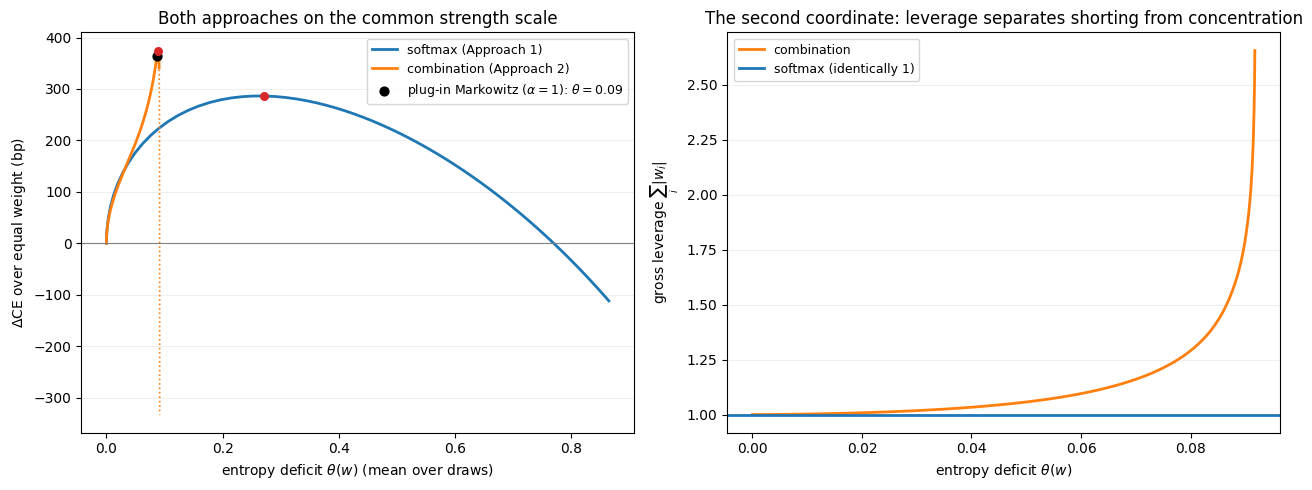

theta at the plug-in Markowitz point (alpha=1): 0.087
theta at alpha* = 1.15: 0.089   |   theta at softmax beta* = 21: 0.272
peak dCE: combination 375 bp vs softmax 286 bp (same draws, same signal)


In [20]:
# ---- both maps on the entropy-deficit axis (baseline case of 3.4 / Exp 3.1) ----
def theta_of(w):
    wt = np.abs(w); wt = wt / wt.sum(axis=1, keepdims=True)
    with np.errstate(divide='ignore', invalid='ignore'):
        H = -np.where(wt > 0, wt * np.log(wt), 0.0).sum(axis=1)
    return 1.0 - H / np.log(N)

th_c = np.array([theta_of(combination_weights(sm, a)).mean() for a in alpha_grid])
th_s = np.array([theta_of(softmax_weights(sm, b)).mean() for b in beta_grid])
CE_sm = np.array([ce_of(softmax_weights(sm, b), Rm) for b in beta_grid])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
stab_c = MSH_a < msh_max
ax.plot(th_s, 1e4 * (CE_sm - CE_sm[0]), lw=2, color='tab:blue', label='softmax (Approach 1)')
ax.plot(th_c[stab_c], dCE_a[stab_c], lw=2, color='tab:orange', label='combination (Approach 2)')
ax.plot(th_c[~stab_c], dCE_a[~stab_c], lw=1.2, ls=':', color='tab:orange')
k1 = np.argmin(np.abs(alpha_grid - 1.0))
ax.scatter([th_c[k1]], [dCE_a[k1]], color='black', zorder=6, s=40,
           label=fr'plug-in Markowitz ($\alpha=1$): $\theta = {th_c[k1]:.2f}$')
ax.scatter([th_c[k]], [dCE_a[k]], color='tab:red', zorder=6, s=30)
ks = int(np.argmax(CE_sm)); ax.scatter([th_s[ks]], [1e4*(CE_sm[ks]-CE_sm[0])], color='tab:red', zorder=6, s=30)
ax.axhline(0, color='grey', lw=0.8)
ax.set_xlabel(r'entropy deficit $\theta(w)$ (mean over draws)')
ax.set_ylabel(r'$\Delta$CE over equal weight (bp)')
ax.set_title('Both approaches on the common strength scale')
ax.grid(axis='y', alpha=0.2)
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(th_c, LEV_a, lw=2, color='tab:orange', label='combination')
ax.axhline(1.0, color='tab:blue', lw=2, label='softmax (identically 1)')
ax.set_xlabel(r'entropy deficit $\theta(w)$')
ax.set_ylabel(r'gross leverage $\sum_i |w_i|$')
ax.set_title(r'The second coordinate: leverage separates shorting from concentration')
ax.grid(axis='y', alpha=0.2)
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f"theta at the plug-in Markowitz point (alpha=1): {th_c[k1]:.3f}")
print(f"theta at alpha* = {astar:.2f}: {th_c[k]:.3f}   |   theta at softmax beta* = {beta_grid[ks]:.0f}: {th_s[ks]:.3f}")
print(f"peak dCE: combination {dCE_a[k]:.0f} bp vs softmax {1e4*(CE_sm[ks]-CE_sm[0]):.0f} bp (same draws, same signal)")

## Methodological notes

**The guard changes the estimand, openly.** Every result is conditional on the normaliser being non-degenerate; the dropped counts are printed next to each experiment so the size of that conditioning is always visible. It is negligible at baseline ($0.14\%$) but grows with signal noise ($5\%$ at $\sigma_\varepsilon = 0.2$) and with covariance roughness ($1.4\%$ in the factor case) — the growth is itself a symptom of the leg's fragility, and flooring the normaliser instead would have hidden it inside a silently different portfolio rule.

**CARA, lognormal prices, and shorting.** With any short position, one-step lognormal prices leave portfolio wealth unbounded below and $\mathbb{E}[e^{-\gamma W}]$ need not be finite; even where it is, the Monte-Carlo average can be dominated by single draws. The max single-draw share of EU is therefore tracked at every grid point, sweeps are shaded (or dotted) where it exceeds $1\%$, and optima are selected only within the stable region — several reported optima (the near-clean levels of Experiment 3.5, the low-noise rows of Experiment 3.6) are consequently *stability-truncated lower bounds* rather than sharp interior points, and are labelled as such in the readings. This is the estimator-level face of the same economics the sweeps show: off the simplex, the cost of over-strength is a tail, not a shoulder.

**$\alpha$ is not comparable across risk models.** Because $\Sigma^{-1}$ rescales the tangency leg, the same $\alpha$ buys very different tilts under different $\Sigma$ (Experiment 3.7's amplification factor of $21$ at $\rho = 0.5$). Within-experiment sweeps are meaningful; cross-experiment strength comparisons should use the entropy-deficit coordinate $\theta$ or the achieved $\Delta$CE. The same warning applied, more mildly, to $\beta$ across signal scales in Experiment 3.

**A linearity curiosity in the P&L view.** The paired difference $D(\alpha) = \boldsymbol{w}(\alpha)^\top\boldsymbol{R} - \boldsymbol{w}(0)^\top\boldsymbol{R} = \alpha\,(\boldsymbol{w}_{\mathrm{sig}} - \boldsymbol{w}_{\mathrm{eq}})^\top\boldsymbol{R}$ is exactly linear in $\alpha$, so the probability of beating equal weight is *the same at every* $\alpha > 0$ ($77.2\%$ here) — strength scales the size of the paired win or loss, never its sign. The softmax's nonlinearity made that probability strength-dependent; the combination map cleanly separates *whether* the signal helps (a property of the draw) from *how much* is staked on it ($\alpha$).

**Common random numbers, inventory.** Seed $42$ reproduces Experiment 3's $(\boldsymbol{\mu}, \boldsymbol{\varepsilon}_0, \boldsymbol{\phi})$ draw-for-draw; seeds $4242$ (common factor) and $7$ (loading matrix and factor shocks) reproduce Experiment 3.3's correlation structures, so every head-to-head is paired with the Approach 1 results, not merely comparable in distribution. The heterogeneous vols and vol-signal noise of Experiment 3.6 use a dedicated stream (seed $4343$) so they perturb nothing upstream. In head-to-heads the softmax is evaluated on the combination's masked sample; the masking changes its optima by well under a basis point (the softmax is defined on all draws), as the reproduction of Experiment 3.3's numbers confirms.

**Numbering.** Notebook Experiments 3.4–3.7 are Experiments 4–7 of the dissertation text: both approaches live in Chapter 3, so the softmax experiments are 3.1–3.3 and the combination experiments continue as 3.4–3.7.